In [1]:
import numpy as np
import matplotlib.pyplot as plt

import helper_functions.optimal_controller as oc
import helper_functions.plotting as plotting

# to get test system
from pypower.api import case14, runpf, printpf, makeYbus
from pypower.idx_bus import *
from pypower.idx_brch import *
from pypower.idx_gen import *


# Helper Functions

In [2]:
def convert_rx_to_gb(r,x,positive_b_inductor=True):
    # We define default z = r + jx and y = g - jb
    # Therefore x>0 -> b>0
    denom = r**2 + x**2
    if positive_b_inductor:
        return r/denom, x/denom
    else:
        return r/denom, -x/denom

def convert_gb_to_rx(g, b, positive_b_inductor=True):
    denom = g**2 + b**2
    if positive_b_inductor:
        return g/denom, b/denom
    else:
        return g/denom, -b/denom
    
def convert_complexy_to_ydq(complexy):
    g = complexy.real
    b = -complexy.imag
    return np.array([[g, b],[-b,g]])

def convert_complexY_to_Ydq(complexY):
    m,n = complexY.shape
    Ydq = np.zeros((2*m, 2*n))
    for i in range(m):
        for k in range(n):
            Ydq[2*i:2*i + 2, 2*k:2*k + 2] = convert_complexy_to_ydq(complexY[i,k])
    return Ydq

def calculate_P_network(Iinvs, Vinvs, perunit=True):
    n = int(len(Iinvs) / 2)
    if perunit:
        return np.sum(Iinvs.reshape(n,2) * Vinvs.reshape(n,2), axis=1)
    return 3 * np.sum(Iinvs.reshape(n,2) * Vinvs.reshape(n,2), axis=1)

def calculate_Q_network(Iinvs, Vinvs, perunit=True):
    n = int(len(Iinvs) / 2)
    J = np.array([[0,1],[-1,0]])
    if perunit:
        return np.sum(Iinvs.reshape(n,2) * (Vinvs.reshape(n,2) @ J), axis=1)
    return 3 * np.sum(Iinvs.reshape(n,2) * (Vinvs.reshape(n,2) @ J), axis=1)

def create_Ybus(network, pf_result):
    nb = network["bus"].shape[0]
    nbr = network["branch"].shape[0]

    base_mva = network["baseMVA"]

    Ybus = np.zeros((nb,nb),dtype=complex)

    # Add self-admittances (diagonal-only elements)
    bus_shunts = (network["bus"][:,GS] + network["bus"][:,BS]*1j)/base_mva # pypower uses y=g+jb
    bus_loads = (pf_result["bus"][:,PD] - pf_result["bus"][:,QD] * 1j)/ (base_mva * pf_result["bus"][:,VM] ** 2) # Convert PD and QD to per unit then divide by squared Vm

    # Inverter shunts are not included in Ybus to avoid double counting later
    np.fill_diagonal(Ybus, bus_shunts + bus_loads)

    # Add mutual admittances (add to diagonals and subtract from off-diagonals)
    for i in range(nbr):
        # Ignore line charging susceptance
        from_bus = int(network["branch"][i, F_BUS])
        to_bus = int(network["branch"][i,T_BUS])
        g, b = convert_rx_to_gb(network["branch"][i, BR_R], network["branch"][i, BR_X], positive_b_inductor=True) # already in pu
        branch_admittance = g - b * 1j
        # Assign negative branch admittances to off-diagonals
        Ybus[from_bus - 1, to_bus - 1] = -branch_admittance
        Ybus[to_bus - 1, from_bus - 1] = -branch_admittance

        # Add branch admittances to diagonals
        Ybus[from_bus - 1, from_bus - 1] += branch_admittance
        Ybus[to_bus - 1, to_bus - 1] += branch_admittance
    return Ybus

def Kron_reduce(Ybus, slack_idx_0based, inv_idx_0based):
    nb = Ybus.shape[0]
    keep_nodes = np.hstack((slack_idx_0based, inv_idx_0based))
    elim_nodes = np.setdiff1d(range(nb), keep_nodes)
    new_order = np.hstack((keep_nodes, elim_nodes))

    # Swap rows
    Ybus = Ybus[new_order, :]

    # Swap columns
    Ybus = Ybus[:,new_order]

    # Do Kron Reduction
    n_keep = len(keep_nodes)
    K = Ybus[:n_keep, :n_keep]
    L = Ybus[:n_keep, n_keep:]
    LT = Ybus[n_keep:, :n_keep]
    M = Ybus[n_keep:, n_keep:]

    Ybus_KRON = K - L @ np.linalg.inv(M) @ LT

    # Now remove infinite bus from Ybus_Kron
    Y_slack = -Ybus_KRON[0,1:]
    # convert Yslack to dq
    Y_slackdq = convert_complexY_to_Ydq(Y_slack.reshape(len(Y_slack),1))
    Ybus_KRON = Ybus_KRON[1:,1:]
    Ybus_KRONdq = convert_complexY_to_Ydq(Ybus_KRON)

    return Ybus_KRONdq, Y_slackdq

In [3]:
def initial_setpoints(slack_id, inverter_bus_ids, pf_result, 
                         Ybus_KRONdq, Y_slackdq, filter_rs, filter_xs):
    # Initialize Vg0 from power flow and solve for the rest
    Z_filters = np.diag(filter_rs + filter_xs * 1j)
    Y_filtersdq = convert_complexY_to_Ydq(np.linalg.inv(Z_filters))
    Z_filtersdq = np.linalg.inv(Y_filtersdq)

    Vslack = np.array([pf_result["bus"][slack_id-1,VM],0])
    Vg0_mags = pf_result["bus"][inverter_bus_ids-1,VM] # voltage magnitudes
    Vg0_angles = np.deg2rad(pf_result["bus"][inverter_bus_ids-1,VA]) # pypower angle converted to radians
    Vgs0 = np.vstack((Vg0_mags * np.cos(Vg0_angles),Vg0_mags * np.sin(Vg0_angles))).T.flatten() # in dq
    Iinvs0 = Ybus_KRONdq @ Vgs0 - Y_slackdq @ Vslack # Approximate currents as I = Y_KRON V_pf
    Vinvs0 = Vgs0 + Iinvs0 @ Z_filtersdq.T
    Ps0 = calculate_P_network(Iinvs0, Vinvs0)
    Qs0 = calculate_Q_network(Iinvs0, Vinvs0)

    return Ps0, Qs0, np.linalg.norm(Vinvs0.reshape(len(inverter_bus_ids),2), axis=1)**2

def multi_inv_simulation(slack_id, inverter_bus_ids, inverter_setpoints, inverter_varnames, 
                         inverter_mag_limits, pf_result, 
                         Ybus_KRONdq, Y_slackdq, filter_rs, filter_xs,
                         rho=0.0001, alpha=1, perunit=True,
                         dt=1e-2, starttime = 0.05, returntime = 10, endtime=1):
    base_mva = pf_result['baseMVA']
    
    Zbus_KRONdq = np.linalg.inv(Ybus_KRONdq)

    Z_filters = np.diag(filter_rs + filter_xs * 1j)
    Y_filtersdq = convert_complexY_to_Ydq(np.linalg.inv(Z_filters))
    Z_filtersdq = np.linalg.inv(Y_filtersdq)

    n_keep = len(inverter_bus_ids)
    ts = np.arange(0, endtime, dt)
    omega = 2*np.pi*60 # just used for converting X to L assuming constant impedance

    Vgs = np.zeros((len(ts),n_keep*2))
    Iinvs = np.zeros((len(ts),n_keep*2))
    Vinvs = np.zeros((len(ts),n_keep*2))
    Vslack = np.array([pf_result["bus"][slack_id-1,VM],0])
    Ps = np.zeros((len(ts),n_keep))
    Qs = np.zeros((len(ts),n_keep))

    # Initialize Vg0 from power flow and solve for the rest
    Vg0_mags = pf_result["bus"][inverter_bus_ids-1,VM] # voltage magnitudes
    Vg0_angles = np.deg2rad(pf_result["bus"][inverter_bus_ids-1,VA]) # pypower angle converted to radians
    Vgs[0,:] = np.vstack((Vg0_mags * np.cos(Vg0_angles),Vg0_mags * np.sin(Vg0_angles))).T.flatten() # in dq
    Iinvs[0,:] = Ybus_KRONdq @ Vgs[0,:] - Y_slackdq @ Vslack # Approximate currents as I = Y_KRON V_pf
    Vinvs[0,:] = Vgs[0,:] + Iinvs[0,:] @ Z_filtersdq.T
    Ps[0,:] = calculate_P_network(Iinvs[0,:], Vinvs[0,:],perunit=perunit)
    Qs[0,:] = calculate_Q_network(Iinvs[0,:], Vinvs[0,:],perunit=perunit)

    # Set the initial setpoints equal to the initial pfresult values
    # TODO: CHANGE to a mix of PQ and PV2 inverters
    original_inv_setpoints = np.vstack((Ps[0,:],np.linalg.norm(Vinvs[0,:].reshape(n_keep,2),axis=1)**2)).T
    #gen_mask = np.isin(pf_result["gen"][:,GEN_BUS], inverter_bus_ids)
    #original_inv_setpoints = np.vstack((pf_result["gen"][gen_mask,PG]/base_mva,pf_result["bus"][inverter_bus_ids-1,VM] **2)).T

    for k,t in enumerate(ts[:-1]):
        xpluses = np.zeros(n_keep*2)
        for inv in range(n_keep):
            if starttime < t < returntime:
                xplus = oc.oc_single_iteration(inverter_setpoints[inv,:], inverter_varnames[inv,:], Iinvs[k,2*inv:2*inv+2], 
                                            filter_rs[inv], filter_xs[inv]/omega, Vgs[k,2*inv:2*inv+2], inverter_mag_limits[inv], omega,
                                                rho=rho, alpha=alpha,
                                                perunit=perunit)
            else:
                xplus = oc.oc_single_iteration(original_inv_setpoints[inv,:], inverter_varnames[inv,:], Iinvs[k,2*inv:2*inv+2], 
                                            filter_rs[inv], filter_xs[inv]/omega, Vgs[k,2*inv:2*inv+2], inverter_mag_limits[inv], omega,
                                                rho=rho, alpha=alpha,
                                                perunit=perunit)                
            xpluses[2*inv:2*inv+2] = xplus
        # Calculate new values across network
        Iinvs[k+1, :] = xpluses
        Vgs[k+1, :] = Zbus_KRONdq @ (Iinvs[k+1, :] + Y_slackdq @ Vslack)
        Vinvs[k+1, :] = Vgs[k+1,:] + Iinvs[k+1,:] @ Z_filtersdq.T
        Ps[k+1,:] = calculate_P_network(Iinvs[k+1,:], Vinvs[k+1,:])
        Qs[k+1,:] = calculate_Q_network(Iinvs[k+1,:], Vinvs[k+1,:])
    return ts, Iinvs, Vinvs, Vgs, Ps, Qs

# 1. Load 14 bus test system and run powerflow

In [4]:
net14 = case14()
base_mva = net14["baseMVA"]
nb = net14["bus"].shape[0]
nbr = net14["branch"].shape[0]
# Initialize "inverters" at non-zero power before solving powerflow
net14["gen"][:,PG] = np.array([60,50,50,50,50])

# Find equilibrium point (run power flow) to initialize simulation
pf_result, success = runpf(net14)

PYPOWER Version 5.1.18, 10-Apr-2025 -- AC Power Flow (Newton)


Newton's method power flow converged in 3 iterations.

Converged in 0.01 seconds
|     System Summary                                                           |

How many?                How much?              P (MW)            Q (MVAr)
---------------------    -------------------  -------------  -----------------
Buses             14     Total Gen Capacity     772.4         -52.0 to 148.0
Generators         5     On-line Capacity       772.4         -52.0 to 148.0
Committed Gens     5     Generation (actual)    261.3              41.3
Loads             11     Load                   259.0              73.5
  Fixed           11       Fixed                259.0              73.5
  Dispatchable     0       Dispatchable           0.0 of 0.0        0.0
Shunts             1     Shunt (inj)             -0.0              21.3
Branches          20     Losses (I^2 * Z)         2.31             13.68
Transformers       3     Branch 

# 2 Construct Ybus Matrix

### Choose inverter filter parameters

In [6]:
# np.random.seed(1024) # for reproducibility
inverter_bus_ids = np.array(net14["gen"][:,GEN_BUS],dtype=int)
slack_id = inverter_bus_ids[0]
inverter_bus_ids = inverter_bus_ids[1:]
filter_xs = np.ones(len(inverter_bus_ids)) * 0.1 # np.random.uniform(0.08, 0.12, 5) # in per unit
filter_rs = np.ones(len(inverter_bus_ids)) * 0.01 # np.random.uniform(0.08, 0.2,5) * filter_xs # in per unit, slightly larger resistances than reactances

# Also find the admittance/impedances matrices to convert inverter currents to inverter voltages knowing network voltages
#Z_filters = np.diag(filter_rs + filter_xs * 1j)
#Y_filtersdq = convert_complexY_to_Ydq(np.linalg.inv(Z_filters))
#Z_filtersdq = np.linalg.inv(Y_filtersdq)

# Convert filter impedances to admittances
# NOTE: pypower defines b>0 as capacitance (y=g+jb), but we define b>0 as inductance (y=g-jb)
# filter_gs, filter_bs = convert_rx_to_gb(filter_rs, filter_xs, positive_b_inductor=True)
# add slack bus with 0 filter
#filter_gs = np.hstack((np.zeros(1), filter_gs))
#filter_bs = np.hstack((np.zeros(1), filter_bs))
#print(slack_id, inverter_bus_ids, filter_gs, filter_bs)

### Loop through buses and branches

In [7]:
Ybus = create_Ybus(net14, pf_result)
Ybus_KRONdq, Y_slackdq = Kron_reduce(Ybus, slack_id-1, inverter_bus_ids-1)
# Zbus_KRONdq = np.linalg.inv(Ybus_KRONdq)

## 3 Dynamic Simulations

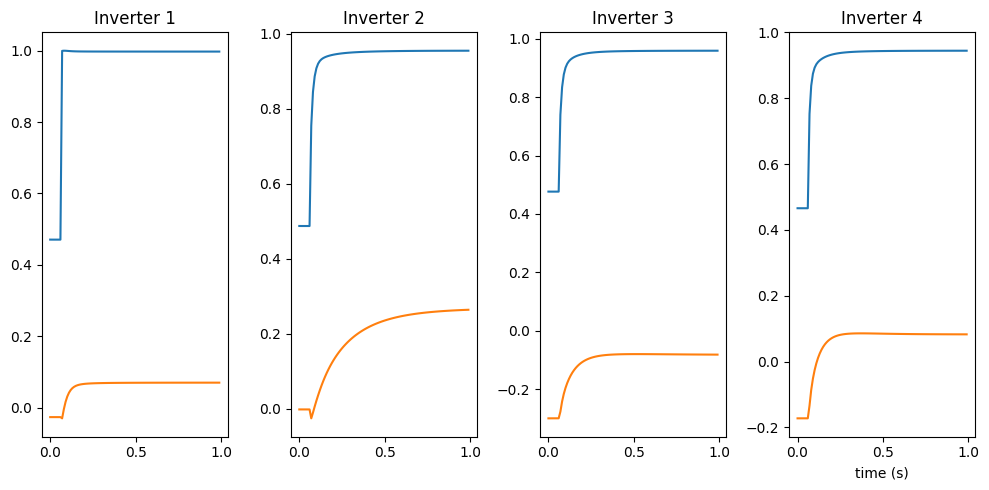

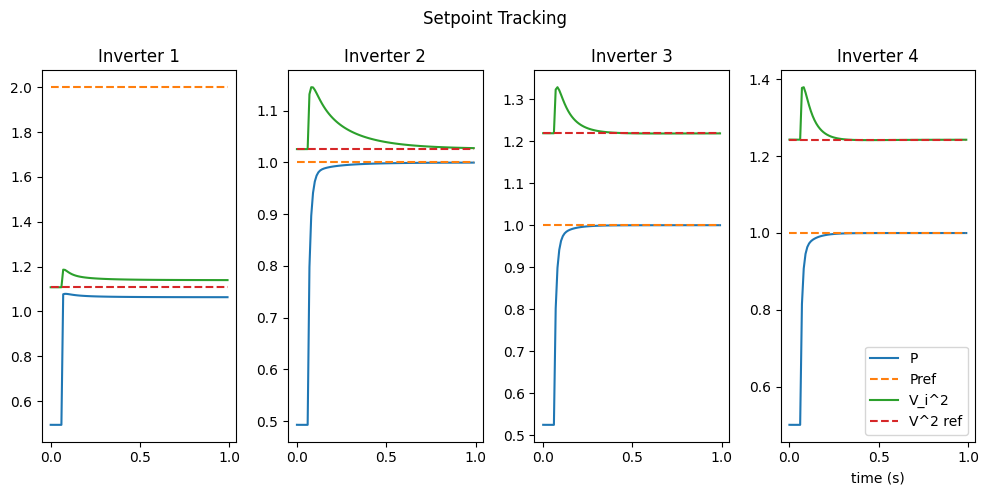

In [10]:
starttime=0.05
endtime = 1
dt = 1e-2
rho = 0.0001
alpha = 2

Ps0, Qs0, V2s0 = initial_setpoints(slack_id, inverter_bus_ids, pf_result,Ybus_KRONdq, Y_slackdq, filter_rs, filter_xs)

gen_mask = np.isin(pf_result["gen"][:,GEN_BUS], inverter_bus_ids)
inverter_setpoints = np.vstack((Ps0, V2s0)).T
inverter_setpoints[:,0] = np.array([2,1,1,1])
inverter_varnames = np.array([["P",r"$V^2$"],["P",r"$V^2$"],["P",r"$V^2$"],["P",r"$V^2$"]]) # variables corresponding to setpoints in above array
inverter_mag_limits = np.ones(len(inverter_bus_ids)) # all limited to 1 pu? check what this value should be - possibly smaller since baseMVA is large

ts, Iinvs, Vinvs, Vgs, Ps, Qs = multi_inv_simulation(slack_id, inverter_bus_ids, inverter_setpoints, inverter_varnames, 
                         inverter_mag_limits, pf_result, 
                         Ybus_KRONdq, Y_slackdq, filter_rs, filter_xs,
                         rho=rho, alpha=alpha,
                         dt=dt, starttime = starttime, endtime=endtime)

# TODO: Calculate and plot Vmag, angle, and frequency over time for inverters and network nodes
fig = plt.figure(figsize=(10,5))
for inv in range(len(inverter_bus_ids)):
    ax = plt.subplot(1, len(inverter_bus_ids), inv+1)
    plt.plot(ts, Iinvs[:,2*inv],label="Id")
    plt.plot(ts, Iinvs[:,2*inv + 1],label="Iq")
    ax.set_title(f"Inverter {inv+1}")
ax.set_xlabel("time (s)")
plt.tight_layout()

fig = plt.figure(figsize=(10,5))
for inv in range(len(inverter_bus_ids)):
    ax = plt.subplot(1, len(inverter_bus_ids), inv+1)
    plt.plot(ts, Ps[:,inv],label="P")
    plt.plot(ts, np.ones(len(ts)) * inverter_setpoints[inv,0],"--",label="Pref")
    plt.plot(ts, np.linalg.norm(Vinvs[:,2*inv:2*inv+2],axis=1)**2, label="V_i^2")
    plt.plot(ts, np.ones(len(ts)) * inverter_setpoints[inv,1],"--",label="V^2 ref")
    ax.set_title(f"Inverter {inv+1}")
    #plt.plot(ts, Qs[:,inv],label="Q")
ax.legend()
ax.set_xlabel("time (s)")
fig.suptitle("Setpoint Tracking")
plt.tight_layout()

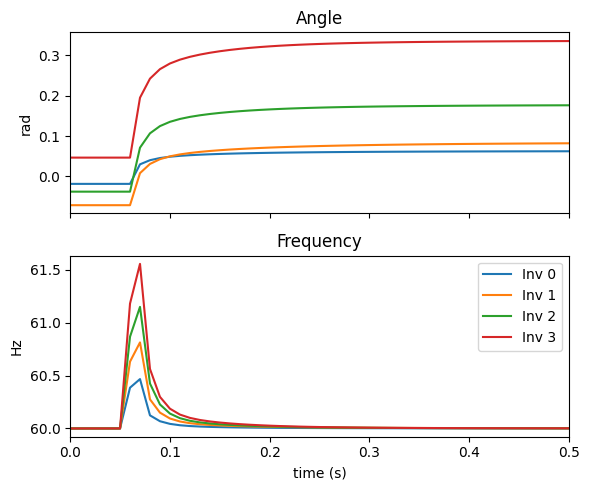

In [11]:
fig, (ax1, ax2) = plt.subplots(2,1,figsize=(6,5),sharex=True)
for inv in range(len(inverter_bus_ids)):
    angle, freq = plotting.angle_and_frequency(Vgs[:,2*inv:2*inv+2], dt)
    ax1.plot(ts, angle,label=f"Inv {inv}")
    ax2.plot(ts, (freq + 2*np.pi*60)/(2*np.pi), label=f"Inv {inv}")
ax1.set_title("Angle")
ax2.set_title("Frequency")
ax1.set_ylabel("rad")
ax2.set_ylabel("Hz")
ax2.set_xlabel("time (s)")
ax2.legend()
ax2.set_xlim(0,0.5)
plt.tight_layout()